### This notebook creates a correlation matrix (rank-based correlations) of catchment features:

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

#### 1. import data:

In [6]:
nutrient_export_data = pd.read_csv('../../output_data/input_ML_learning/median_cnp_export_abs_conc_and_rfr_and_basin_feat.csv').drop(columns='Unnamed: 0')

In [7]:
nutrient_features = nutrient_export_data.drop(columns = ['HYBAS_ID', 'c_imbal', 'n_imbal', 'p_imbal', 'median_DOC_TOC_bioav', 'median_DIN', 'median_SRP'])

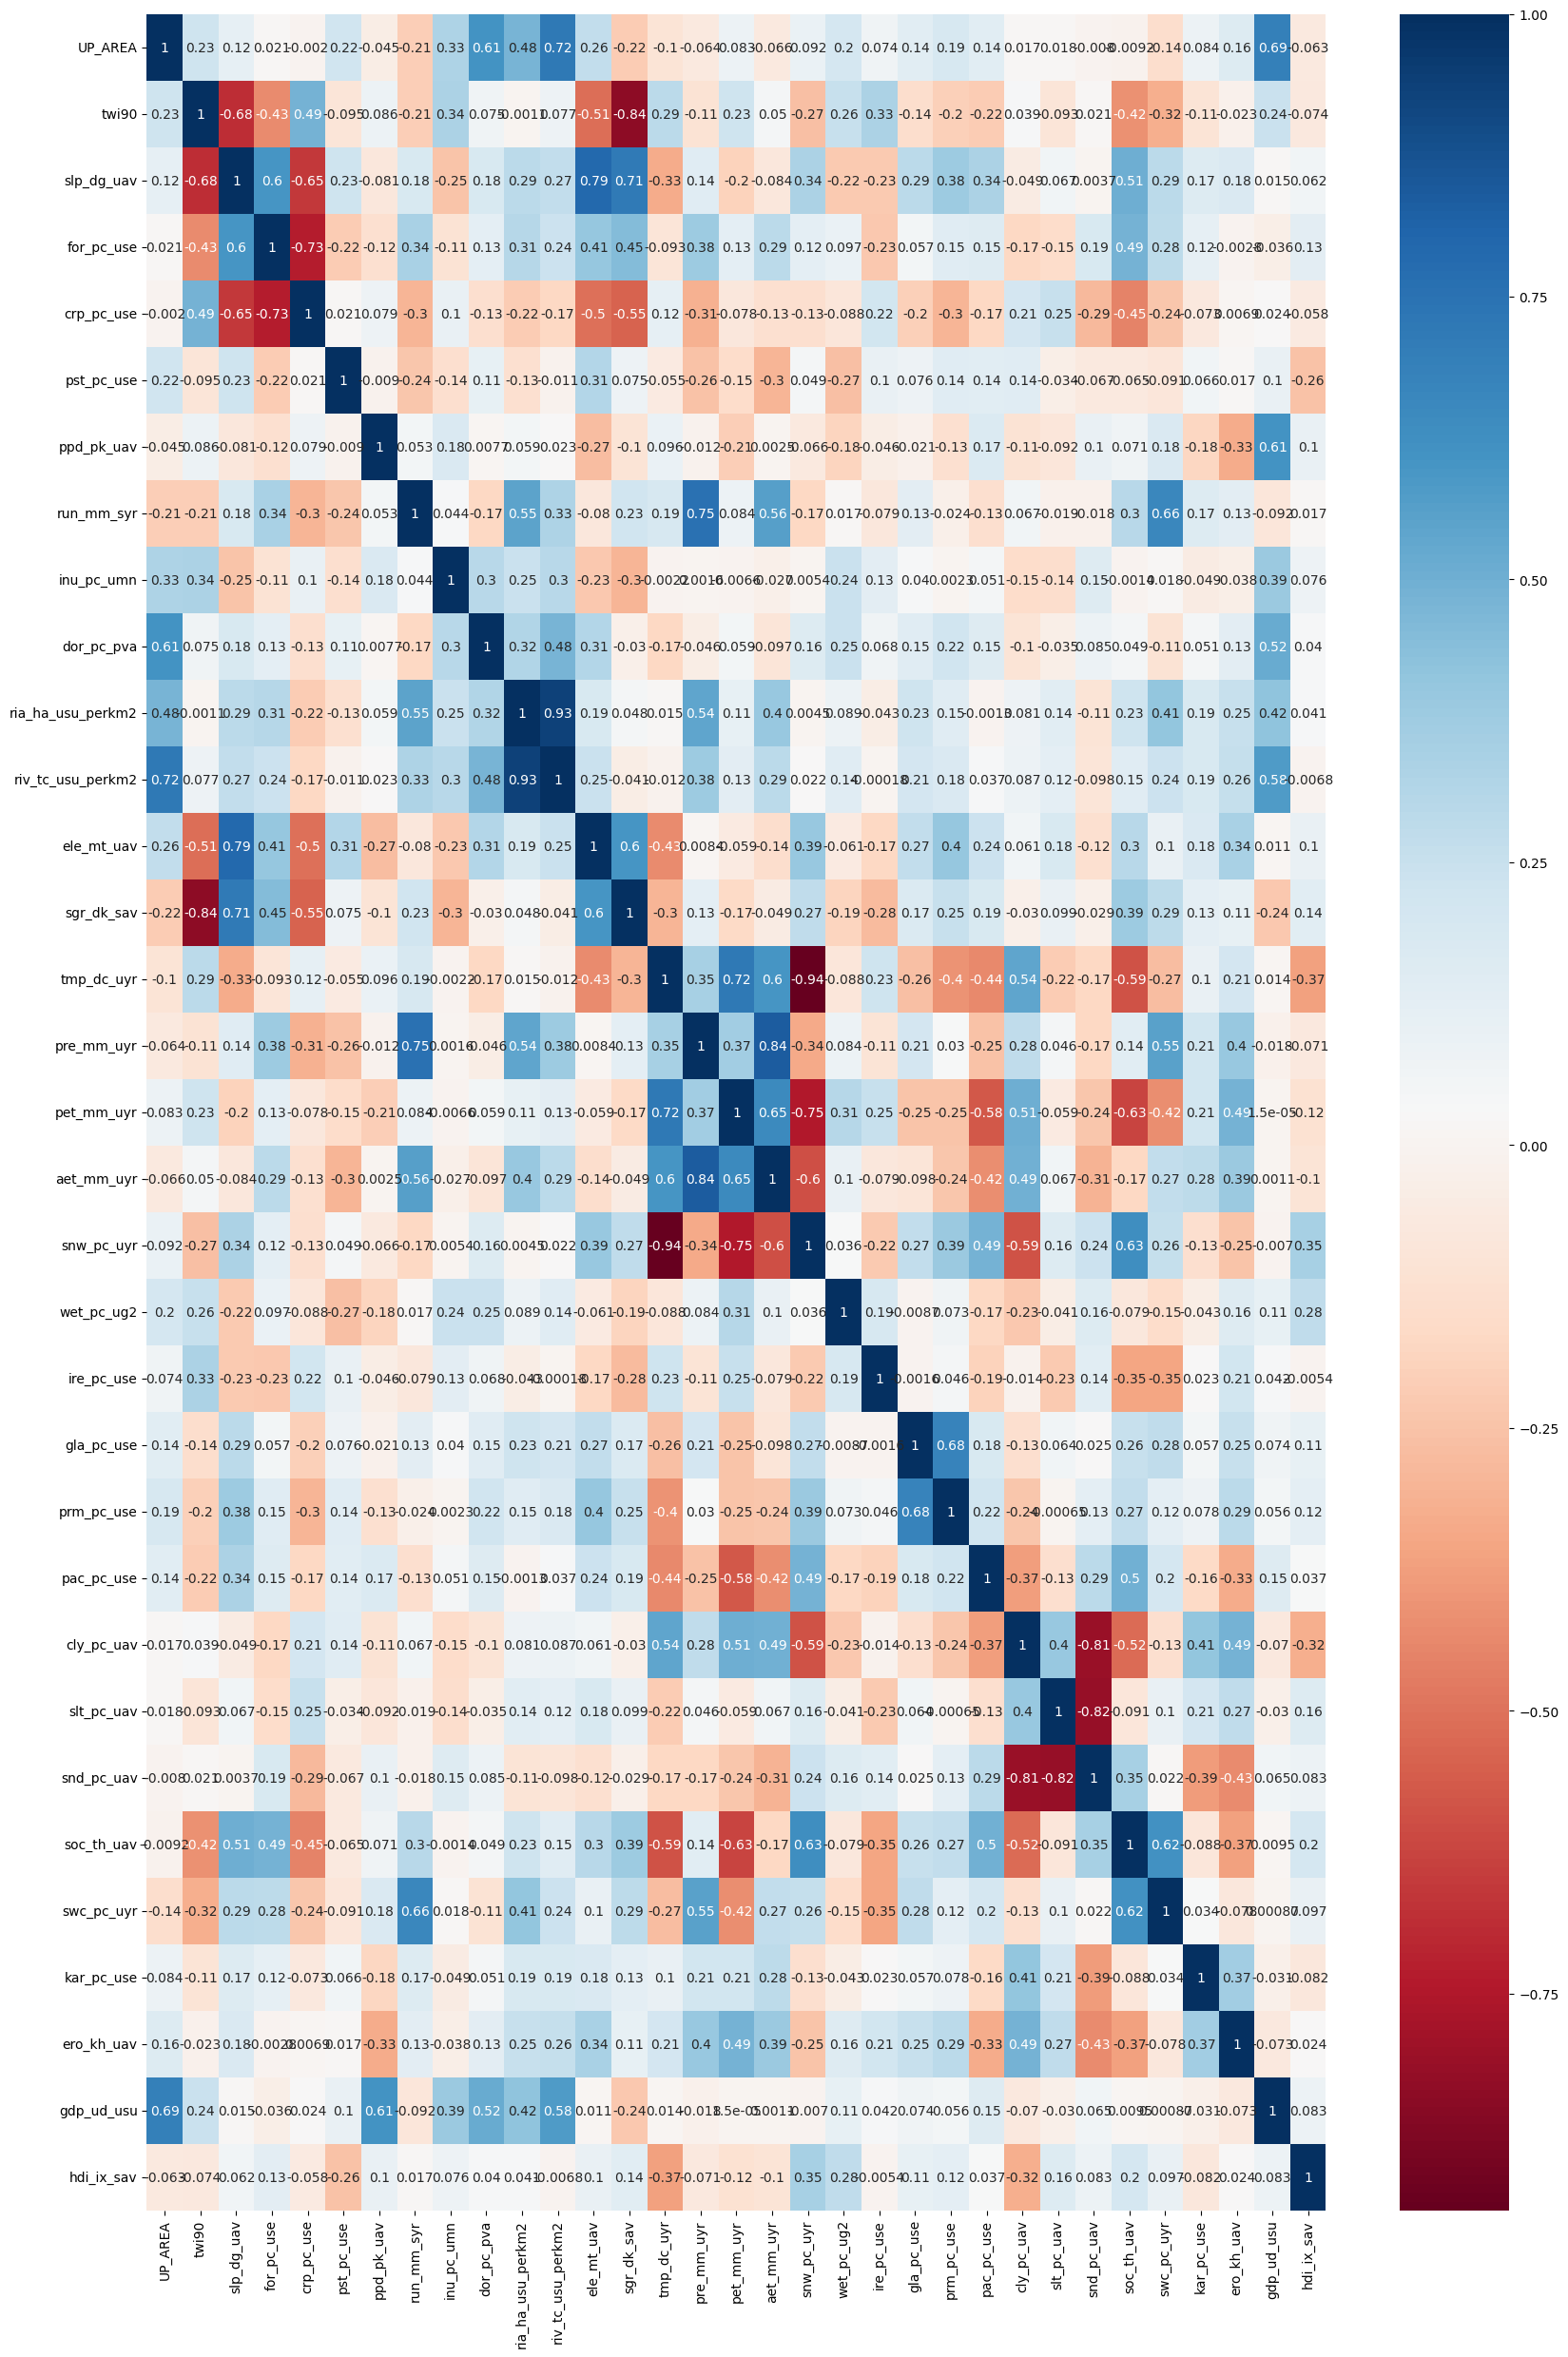

In [8]:

plt.figure(figsize=(20,30))
sns.heatmap(nutrient_features.corr(method = 'spearman'),annot=True, cmap = 'RdBu')
#plt.savefig('correlations.png', dpi = 200)
plt.show()

In [9]:
df_features_all = pd.DataFrame(nutrient_export_data)

df_features_all = df_features_all.drop(columns = {'HYBAS_ID', 'median_DOC_TOC_bioav', 'median_DIN', 'median_SRP'})

In [10]:
df_features_all.columns

Index(['c_imbal', 'n_imbal', 'p_imbal', 'UP_AREA', 'twi90', 'slp_dg_uav',
       'for_pc_use', 'crp_pc_use', 'pst_pc_use', 'ppd_pk_uav', 'run_mm_syr',
       'inu_pc_umn', 'dor_pc_pva', 'ria_ha_usu_perkm2', 'riv_tc_usu_perkm2',
       'ele_mt_uav', 'sgr_dk_sav', 'tmp_dc_uyr', 'pre_mm_uyr', 'pet_mm_uyr',
       'aet_mm_uyr', 'snw_pc_uyr', 'wet_pc_ug2', 'ire_pc_use', 'gla_pc_use',
       'prm_pc_use', 'pac_pc_use', 'cly_pc_uav', 'slt_pc_uav', 'snd_pc_uav',
       'soc_th_uav', 'swc_pc_uyr', 'kar_pc_use', 'ero_kh_uav', 'gdp_ud_usu',
       'hdi_ix_sav'],
      dtype='object')

### Create a function which plots a sorted correlation matrix:

In [16]:
def corr_matrix_target(data, target_var):
    
    # import required modules:
    from scipy.stats import spearmanr
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    
    if target_var == 'c_imbal':
        df_features = data.drop(columns = {'n_imbal', 'p_imbal'})
    if target_var == 'n_imbal':
        df_features = data.drop(columns = {'c_imbal', 'p_imbal'})

    if target_var == 'p_imbal':
        df_features = data.drop(columns = {'n_imbal', 'c_imbal'})
    
    
    # prepare dataframes for correlations and p-values:
    
    corr_matrix = pd.DataFrame(index = df_features.columns, columns = df_features.columns)
    p_values = pd.DataFrame(index = df_features.columns, columns = df_features.columns)
    
    # Calculate correlations and p-values between each pair of variables:
    for col1 in df_features.columns:
        for col2 in df_features.columns:
            corr, p = spearmanr(df_features[col1], df_features[col2])
            corr_matrix.at[col1, col2] = corr
            p_values.at[col1, col2] = p
    
    
    # now sort columns of correlation matrix by descending correlation strength:
    
    correlations_with_c_imbal = corr_matrix[target_var].sort_values(ascending = False)
    sorted_cols = correlations_with_c_imbal.index.to_list()
    
    #sort rows and columns of correlation matrix and p_value_matrix
    sorted_corr_matrix = corr_matrix.loc[sorted_cols, sorted_cols]
    
    sorted_p_values = p_values.loc[sorted_cols, sorted_cols]
    
    
    
    # create a heatmap and annotate:
    
    plt.figure(figsize = (20, 18))
    sns.heatmap(sorted_corr_matrix.astype(float), annot = True, fmt = ".2f", cmap = "coolwarm",
               linewidths = .5, cbar_kws = {"shrink":0.8},
                annot_kws = {"size":6})
    
    # Loop over data dimensions and create text annotations:
    
    for i, row in enumerate(sorted_corr_matrix.index):
        for j, col in enumerate(sorted_corr_matrix.columns):
            if sorted_p_values.iloc[i, j] <0.05:
                # add significance asterisk:
                text = plt.gca().texts[i * len(sorted_corr_matrix.columns) + j]
                plt.gca().texts[i * len(sorted_corr_matrix.columns) + j].set_text(text.get_text() + '*')
    
    plt.title(f"Spearmans rank correlation Heatmap with significance target {target_var} Redfield normalized", size = 16)
    #plt.savefig(f'../../output_data/ML_analysis/catchment_features/corr_matrix_{target_var}.png')
    plt.show()

### 1. correlation matrix with target variable c_imbal:

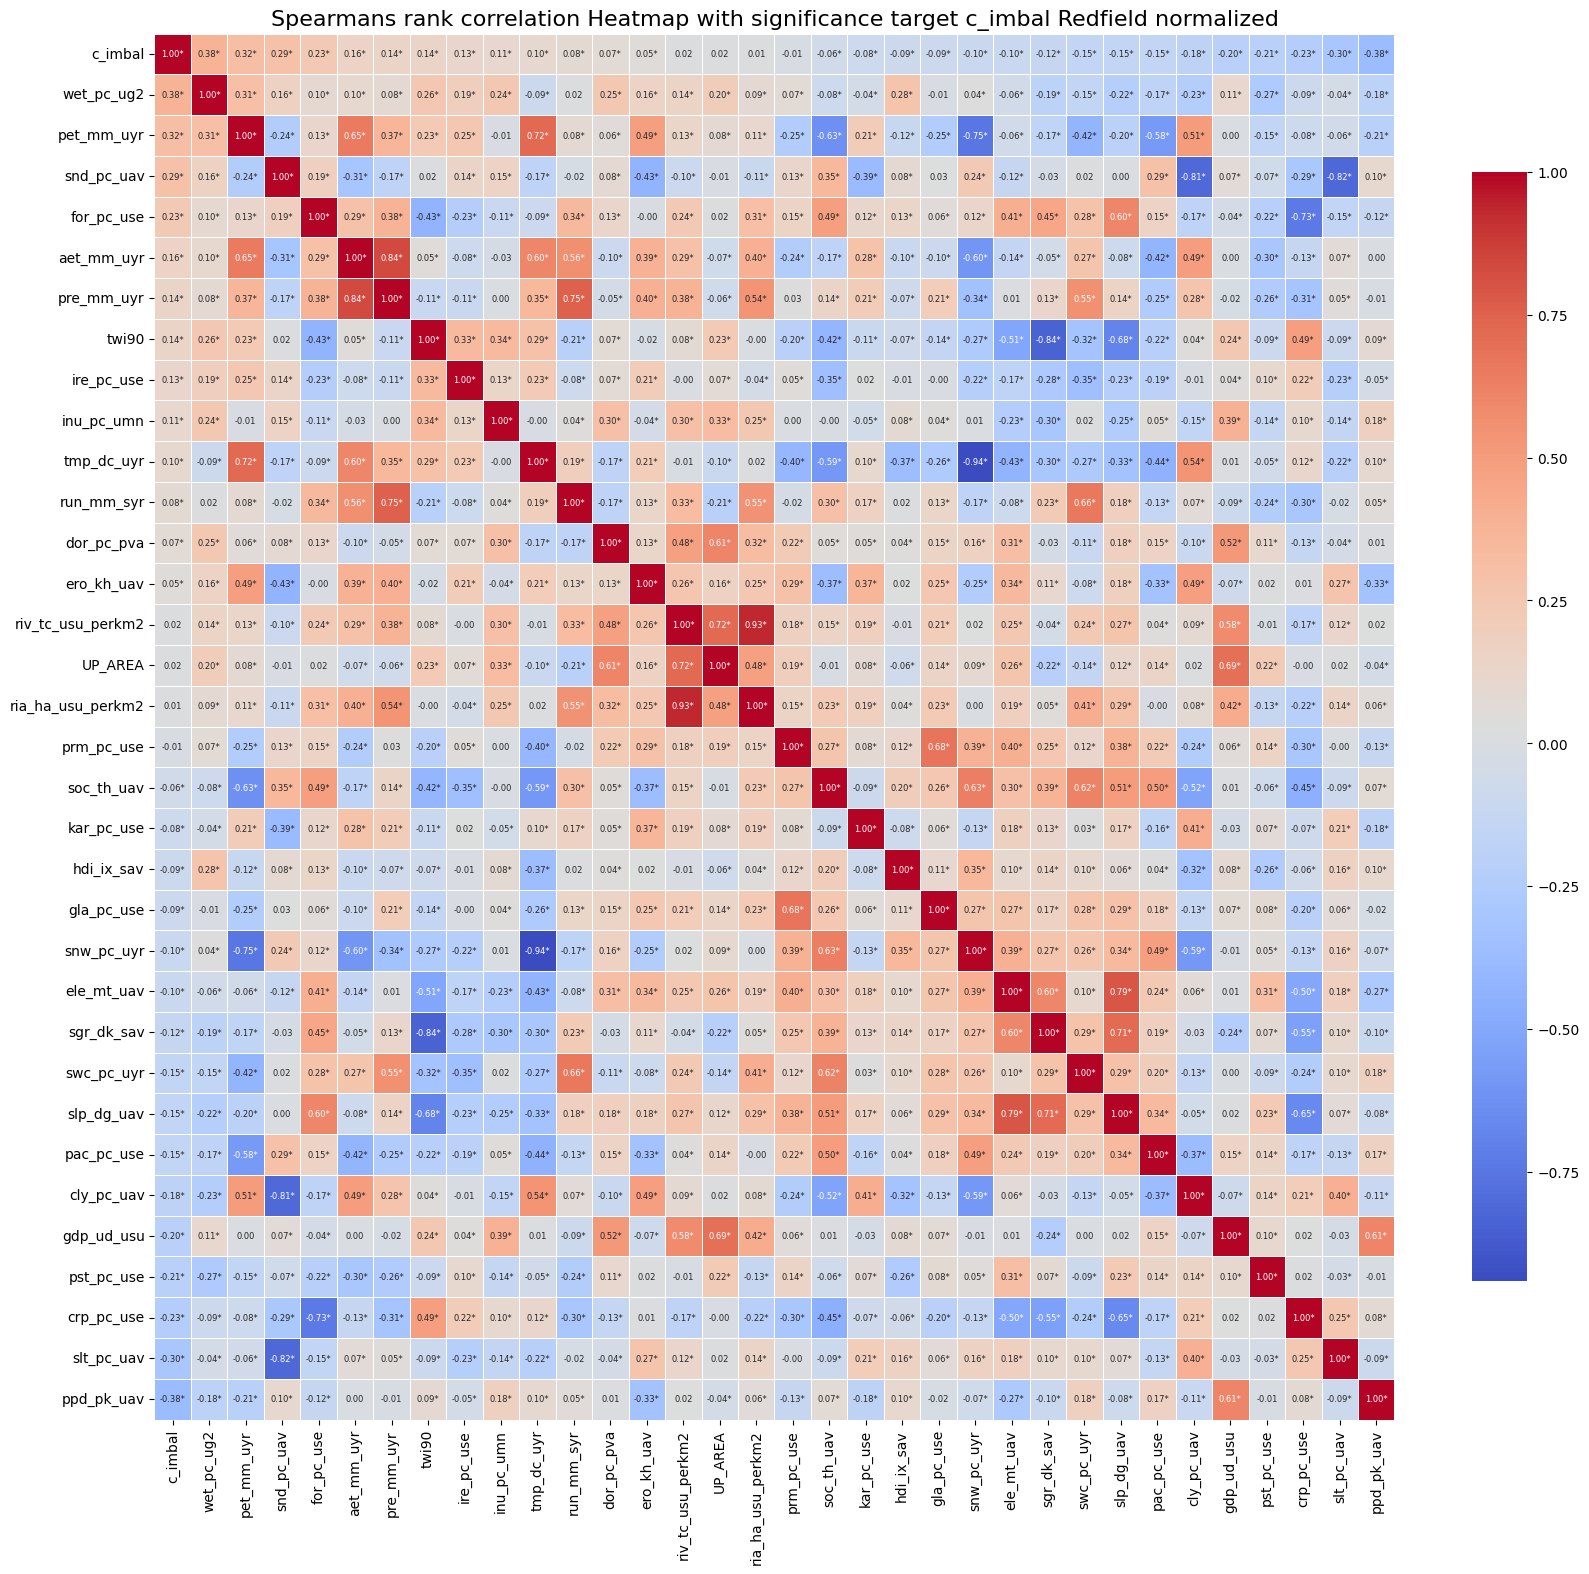

In [17]:
corr_matrix_target(data = df_features_all, target_var = 'c_imbal')

### 2. correlation matrix with target variable n_imbal:

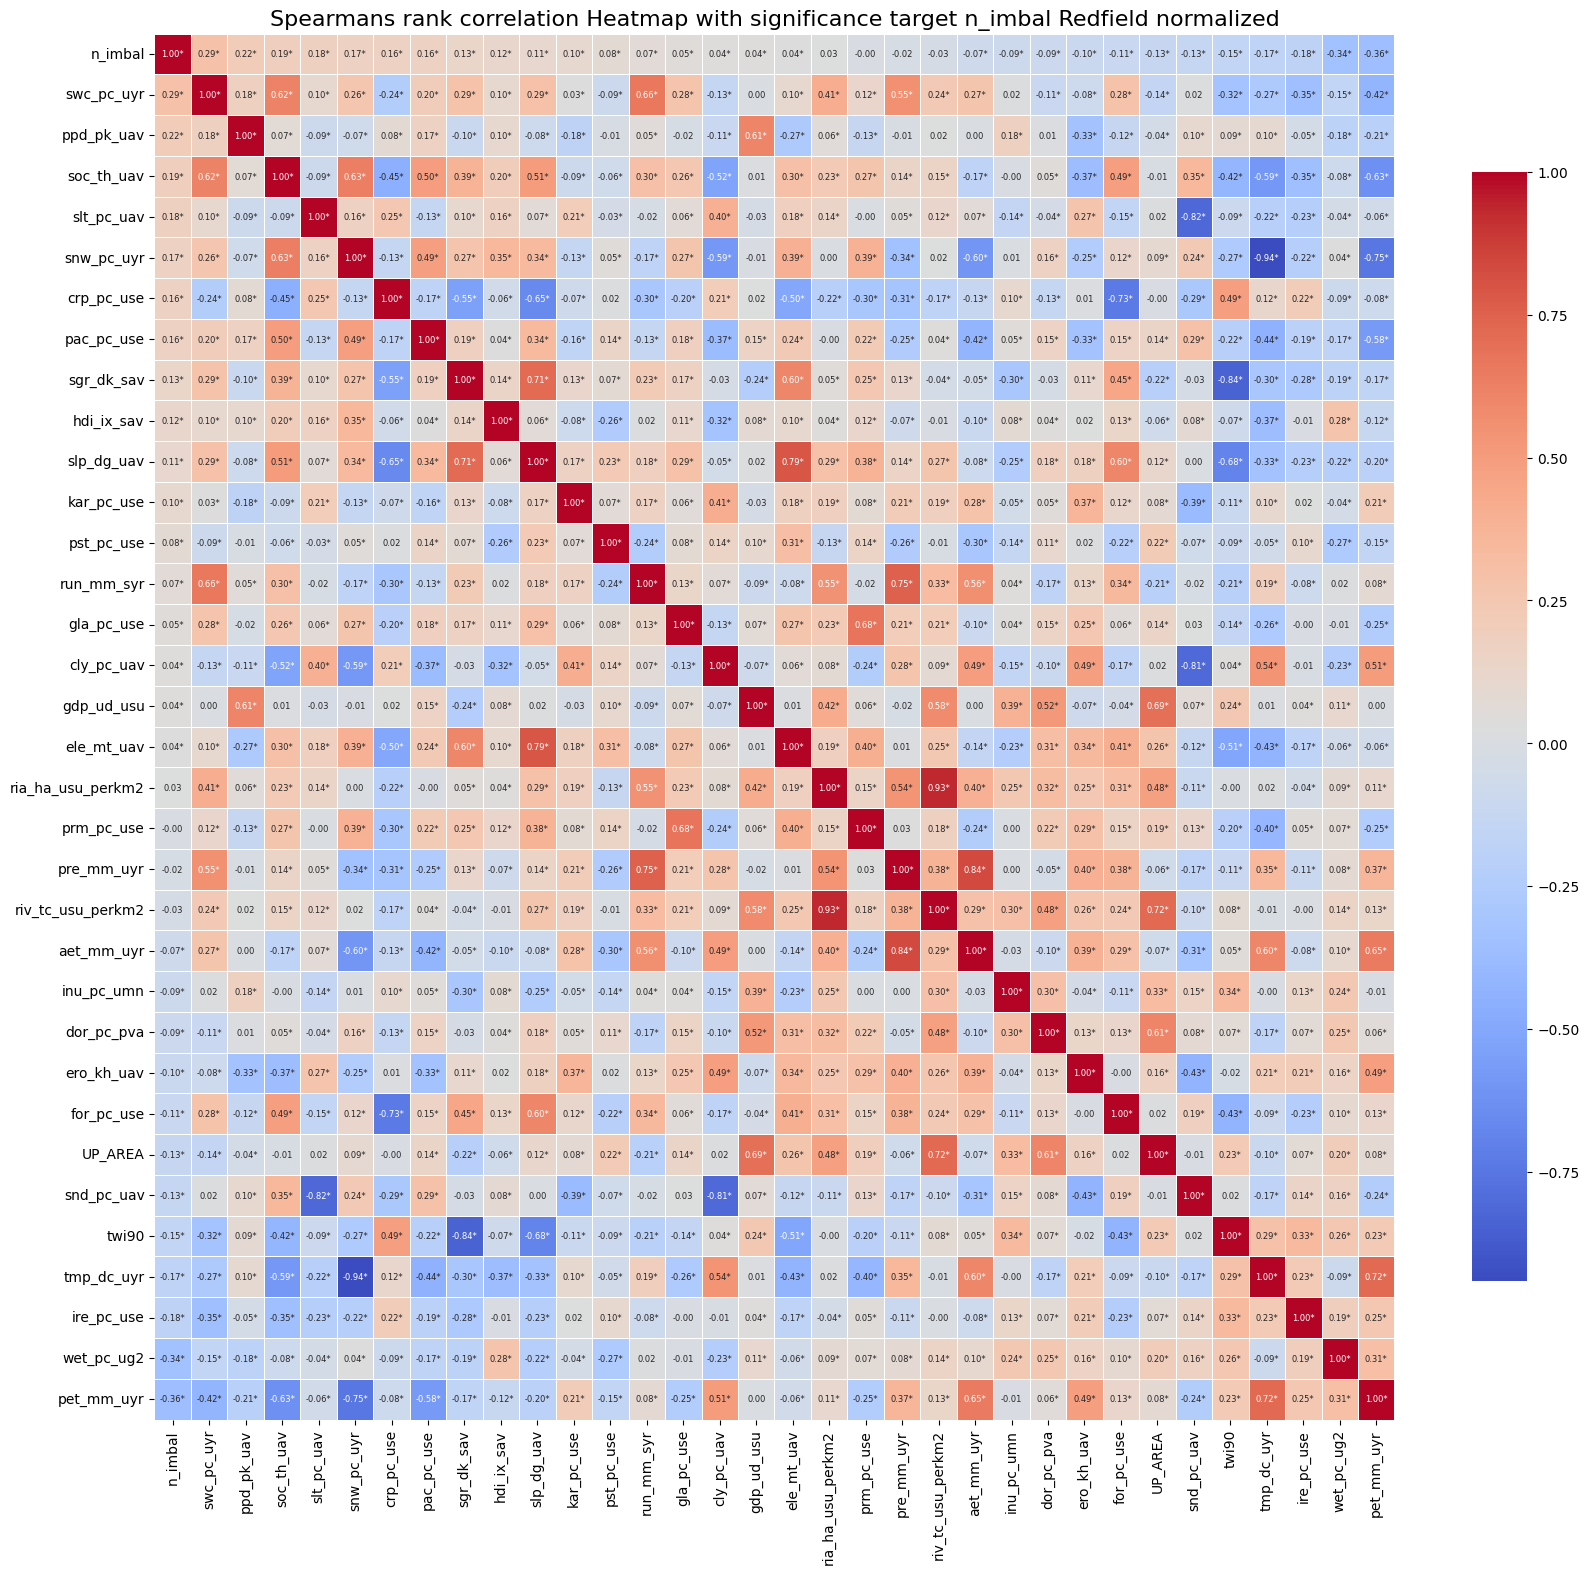

In [18]:
corr_matrix_target(data = df_features_all, target_var = 'n_imbal')

In [19]:
### 3. correlation matrix with target variable p_imbal

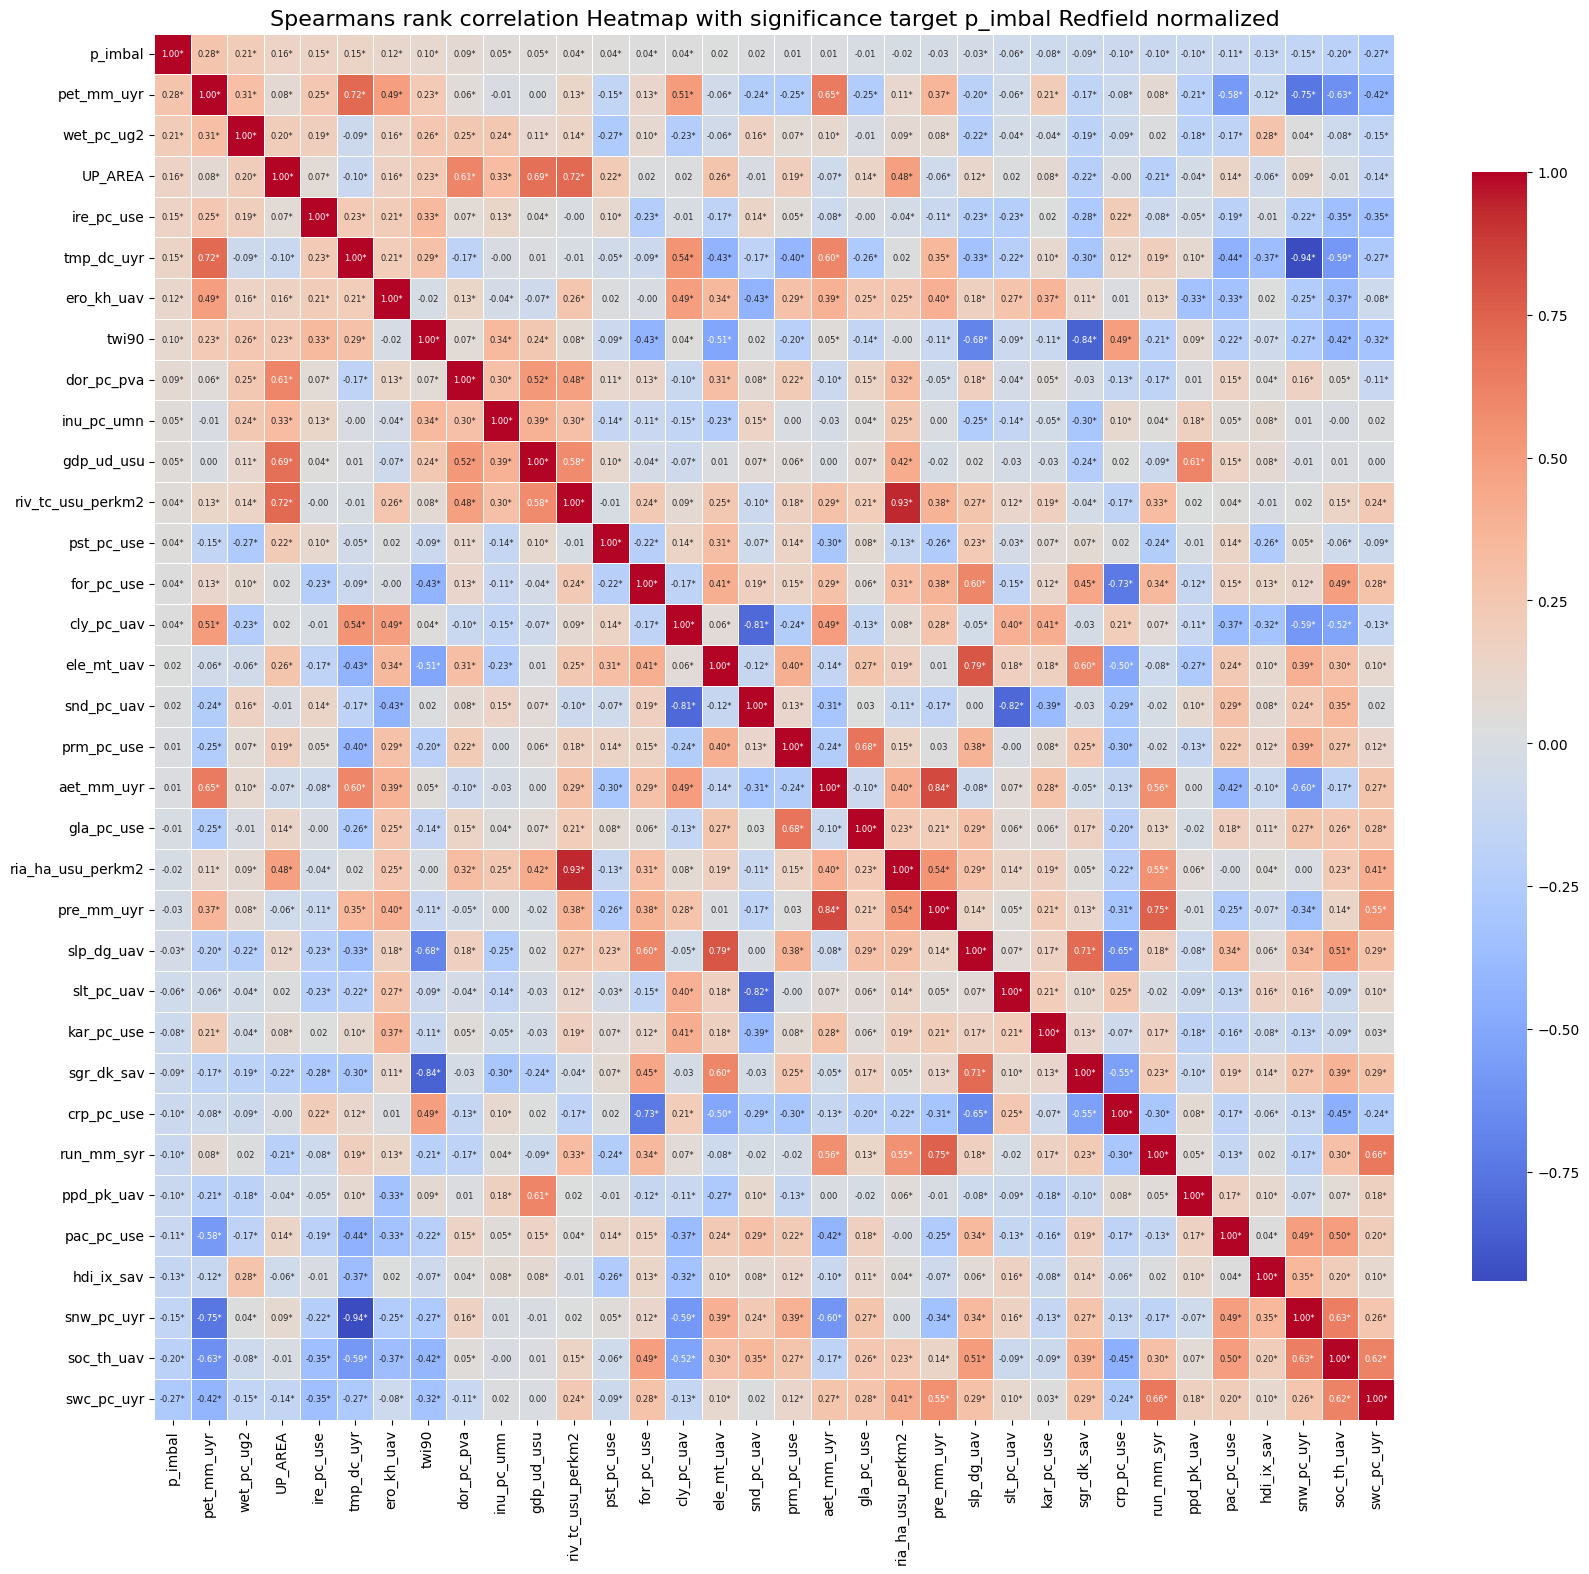

In [20]:
corr_matrix_target(data = df_features_all, target_var = 'p_imbal')

### Another correlation matrix 

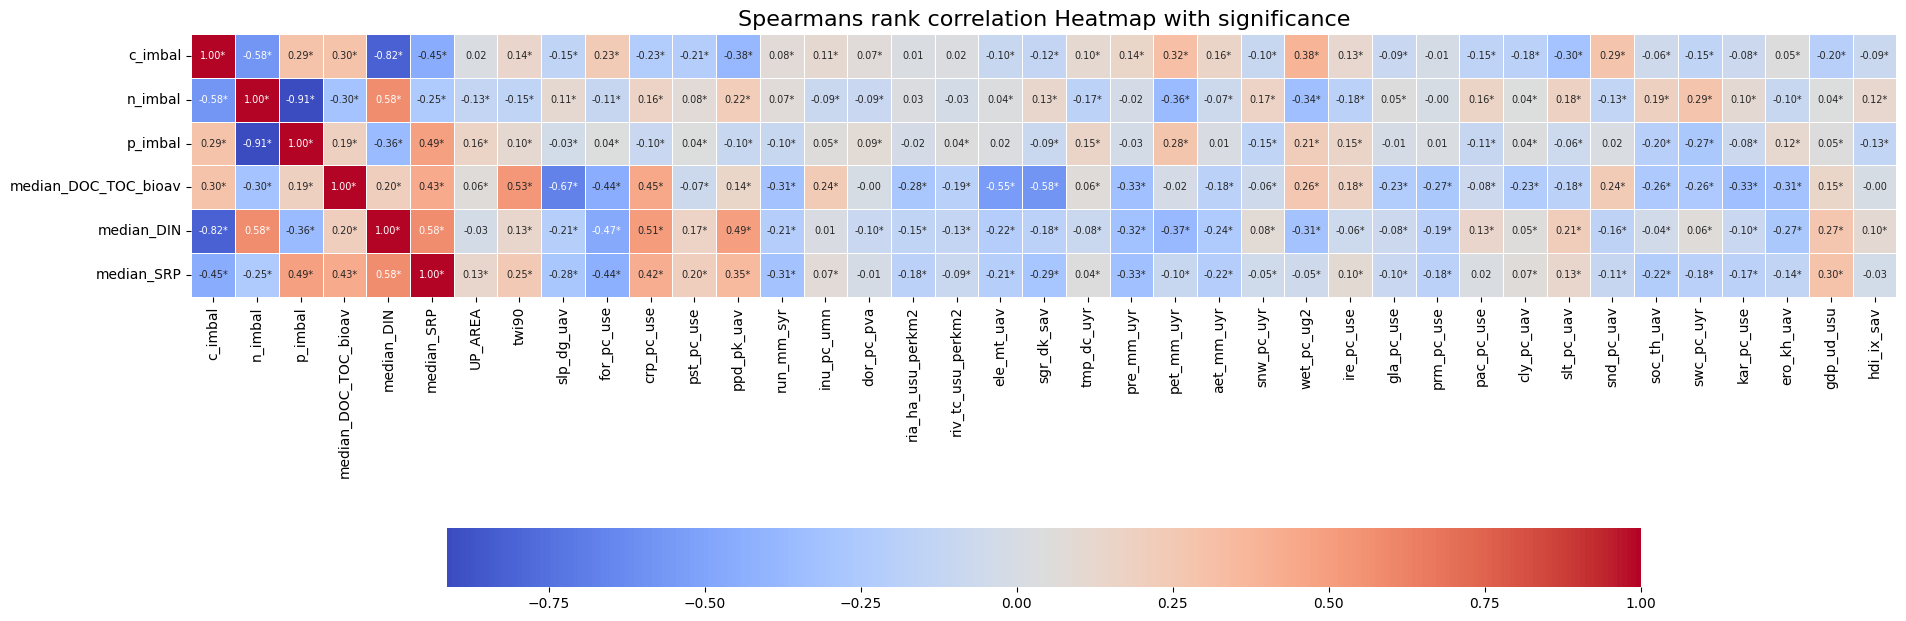

In [24]:
df_features_all = pd.DataFrame(nutrient_export_data)

df_features = df_features_all.drop(columns = {'HYBAS_ID'})
corr_matrix = pd.DataFrame(index = ['c_imbal', 'n_imbal', 'p_imbal',  'median_DOC_TOC_bioav', 'median_DIN', 'median_SRP'], columns = df_features.columns)
p_values = pd.DataFrame(index = ['c_imbal', 'n_imbal', 'p_imbal',  'median_DOC_TOC_bioav', 'median_DIN', 'median_SRP'], columns = df_features.columns)
    
    # Calculate correlations and p-values between each pair of variables:
for col1 in df_features.columns:
    for ind in corr_matrix.index:
        corr, p = spearmanr(df_features[col1], df_features[ind])
        corr_matrix.at[ind, col1] = corr
        p_values.at[ind, col1] = p
    
    
   
    
    # create a heatmap and annotate:
    
plt.figure(figsize = (22, 20))
sns.heatmap(corr_matrix.astype(float), annot = True, fmt = ".2f", cmap = "coolwarm",
               linewidths = .5, cbar_kws = {"shrink":0.7, 'orientation':'horizontal'},
                annot_kws = {"size":7}, square = True)
    
    # Loop over data dimensions and create text annotations:
    
for i, row in enumerate(corr_matrix.index):
    for j, col in enumerate(corr_matrix.columns):
       if p_values.iloc[i, j] <0.05:
                # add significance asterisk:
           text = plt.gca().texts[i * len(corr_matrix.columns) + j]
           plt.gca().texts[i * len(corr_matrix.columns) + j].set_text(text.get_text() + '*')
plt.title(f"Spearmans rank correlation Heatmap with significance", size = 16)
#plt.savefig('corr_matrix_targets.png')
plt.show()

### Because features are already excluded here again with all features:

In [26]:
# 1.) load C:N:P data and prepare as input: 

##### Read in input data:-----
exp_data_daily = pd.read_csv("../../output_data/CNP_data_catchments/basin_exp_DOC_TOC_DIN_SRP_daily_median_mgL_selected.csv")

exp_data_daily.drop(columns =["obs_date"], inplace = True)



# Calculate mol ----
c_gmol = 12.01
n_gmol = 14.01
p_gmol = 30.97

# functions normalization redfield ratio: 
def c_imbal_eq_rfr(cmol,nmol,pmol):
    return (cmol / 106) / ((cmol / 106) + (nmol / 16) + (pmol))

def n_imbal_eq_rfr(cmol, nmol, pmol):
    return (nmol / 16) / ((cmol / 106) + (nmol / 16) + (pmol))

def p_imbal_eq_rfr(cmol,nmol,pmol):
    return pmol / ((cmol / 106) + (nmol / 16) + (pmol))
 


In [27]:

# prepare exported C:N:P data:

# add column of bioavailable OC: assumption 10.08 % are bioavailable: 

exp_data_daily["DOC_TOC_bioav"] = exp_data_daily["DOC_TOC_median"] * 0.1008
 
median_HYBAS_SRP_agg = exp_data_daily.groupby('HYBAS_ID',  as_index=False).median()

median_HYBAS_SRP_agg.rename(columns={
    'DOC_TOC_bioav': 'median_DOC_TOC_bioav',
    'DIN_median': 'median_DIN',
    'SRP_median': 'median_SRP'}, inplace=True)


# convert exported nutrients from mg/L to g/L, and subsequently to mol/L and finally molar ratios relative to the Redfield ratio: 

data_rfr_srp = median_HYBAS_SRP_agg.copy() 

# convert concentrations from mg/L to g/L
data_rfr_srp["DOC_TOC_gL_bioav"] = data_rfr_srp["median_DOC_TOC_bioav"]/1000
data_rfr_srp["DIN_gL"] = data_rfr_srp["median_DIN"]/1000
data_rfr_srp["SRP_gL"] = data_rfr_srp["median_SRP"]/1000

# convert to mol per liter:

data_rfr_srp["docb_mol"] = data_rfr_srp["DOC_TOC_gL_bioav"]/c_gmol
data_rfr_srp["nreact_mol"] = data_rfr_srp["DIN_gL"]/n_gmol
data_rfr_srp["srp_mol"] = data_rfr_srp["SRP_gL"]/p_gmol

# normalize molar  concentrations relative the redfield ratio:

data_rfr_srp["c_imbal"] = c_imbal_eq_rfr(cmol = data_rfr_srp["docb_mol"], nmol = data_rfr_srp["nreact_mol"], pmol = data_rfr_srp["srp_mol"])
data_rfr_srp["n_imbal"] = n_imbal_eq_rfr(cmol = data_rfr_srp["docb_mol"], nmol = data_rfr_srp["nreact_mol"], pmol = data_rfr_srp["srp_mol"])
data_rfr_srp["p_imbal"] = p_imbal_eq_rfr(cmol = data_rfr_srp["docb_mol"], nmol = data_rfr_srp["nreact_mol"], pmol = data_rfr_srp["srp_mol"])



###  select(HYBAS_ID, c_imbal, n_imbal, p_imbal)
data_rfr_srp = data_rfr_srp[['HYBAS_ID', 'c_imbal', 'n_imbal', 'p_imbal', 'median_DOC_TOC_bioav', 'median_DIN', 'median_SRP']]




basin_atlas_lev12_available = pd.read_csv("../../output_data/CNP_data_catchments/basin_atlas_v10_l12_data_available.csv")


# extract latitude of basins: 
export_all = pd.read_csv("../../output_data/CNP_data_catchments/DOC_TOC_DIN_SRP_daily_median_sd_subbasins.csv")

basin_lat = export_all[['HYBAS_ID', 'centroid_lat']]
basin_lat = basin_lat.drop_duplicates(subset = 'HYBAS_ID', keep = "first")

# load TWI90 values:

twi90 = pd.read_csv("../../output_data/TWI_QGIS_and_TWI90_extraction/TWI90_DOC_TOC_DIN_SRP_subbasins.csv")
twi90.drop(columns = 'Unnamed: 0', inplace = True)  


# merge basin_lat, twi90 and basin_atlas_lev12_available

# use basin_lat as primary df, because this df comprises all 3496 catchments for which we have data: 

HYBAS_att = pd.merge(basin_lat, twi90, how="left", on=["HYBAS_ID"])

HYBAS_att2 = pd.merge(HYBAS_att, basin_atlas_lev12_available, on = ["HYBAS_ID"])

# discharge, STREAM_VOLUME, STREAM_AREA durch UP_AREA teilen--> sann catchment area behalten
# 'dis_m3_pyr' --> mean annual discharge
# 'dis_m3_pmn' --> min annual discharge
# 'dis_m3_pmx' --> max annual discharge
# 'riv_tc_usu' --> river volume
# 'ria_ha_usu --> river area in hectares
# mean annual discharge:
HYBAS_att2['dis_m3_pyr_perkm2'] = HYBAS_att2['dis_m3_pyr']/HYBAS_att2['UP_AREA']
# min annual discharge:
HYBAS_att2['dis_m3_pmn_perkm2'] = HYBAS_att2['dis_m3_pmn']/HYBAS_att2['UP_AREA']
# max annual discharge:
HYBAS_att2['dis_m3_pmx_perkm2'] = HYBAS_att2['dis_m3_pmx']/HYBAS_att2['UP_AREA']
# river volume: 
HYBAS_att2['riv_tc_usu_perkm2'] = HYBAS_att2['riv_tc_usu']/HYBAS_att2['UP_AREA']
# river area: 
HYBAS_att2['ria_ha_usu_perkm2'] = HYBAS_att2['ria_ha_usu']/HYBAS_att2['UP_AREA']

HYBAS_att2.rename(columns = {'centroid_lat':'latitude'}, inplace = True)

list_features = ['latitude','UP_AREA' ,'twi90', 'slp_dg_uav', 'for_pc_use', 'crp_pc_use', 'pst_pc_use', 'urb_pc_use', 'ppd_pk_uav',
               'dis_m3_pyr_perkm2', 'dis_m3_pmn_perkm2', 'dis_m3_pmx_perkm2', 'run_mm_syr', 'inu_pc_umn', 'inu_pc_umx', 'inu_pc_ult', 'dor_pc_pva',
                'ria_ha_usu_perkm2', 'riv_tc_usu_perkm2',
                'gwt_cm_sav', 'ele_mt_uav', 'sgr_dk_sav', 'tmp_dc_uyr', 'pre_mm_uyr', 'pet_mm_uyr', 'aet_mm_uyr', 'ari_ix_uav',
                'cmi_ix_uyr', 'snw_pc_uyr', 'wet_pc_ug2', 'ire_pc_use', 'gla_pc_use', 'prm_pc_use', 'pac_pc_use', 'cly_pc_uav',
                'slt_pc_uav', 'snd_pc_uav', 'soc_th_uav', 'swc_pc_uyr', 'kar_pc_use', 'ero_kh_uav', 'hft_ix_u09',
                'gdp_ud_usu', 'hdi_ix_sav']



#

# filter only selected features
basin_features = HYBAS_att2[list_features]



In [28]:
basin_features

,latitude,UP_AREA,twi90,slp_dg_uav,for_pc_use,crp_pc_use,pst_pc_use,urb_pc_use,ppd_pk_uav,dis_m3_pyr_perkm2,...,cly_pc_uav,slt_pc_uav,snd_pc_uav,soc_th_uav,swc_pc_uyr,kar_pc_use,ero_kh_uav,hft_ix_u09,gdp_ud_usu,hdi_ix_sav
0,-0.093524,20609.9,8.826505,48,42,5,22,18,217.847,0.009813,...,32,23,44,27,49,0,11117,117,1.175299e+10,555
1,-0.155532,18829.3,8.074445,50,44,5,22,19,226.722,0.010192,...,32,23,44,28,51,0,11470,120,1.130367e+10,555
2,-0.221305,109.9,8.204151,67,99,3,12,54,366.090,0.013567,...,36,26,39,35,68,0,12078,140,6.879562e+07,555
3,-0.299655,265.1,9.421020,89,71,2,19,24,185.508,0.013003,...,33,26,41,56,75,0,11736,76,8.293591e+07,555
4,-0.320214,32034.9,9.312500,35,28,6,31,12,151.100,0.006062,...,32,24,44,22,38,0,7784,95,1.263985e+10,555
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3491,61.863703,80185.4,6.915997,91,14,0,0,0,0.006,0.014663,...,13,42,43,106,85,2,1660,1,4.468250e+07,948
3492,61.810415,111.5,5.486714,222,5,0,0,0,0.000,0.016897,...,7,34,58,148,89,0,3379,26,2.679400e+05,948
3493,60.492898,5195.2,15.634457,128,28,0,0,0,3.149,0.031610,...,10,37,52,122,91,0,2878,27,9.341507e+08,948
3494,59.829318,180.3,8.519233,33,22,0,0,0,5.139,0.018136,...,10,45,45,133,89,0,64,47,6.378524e+07,948


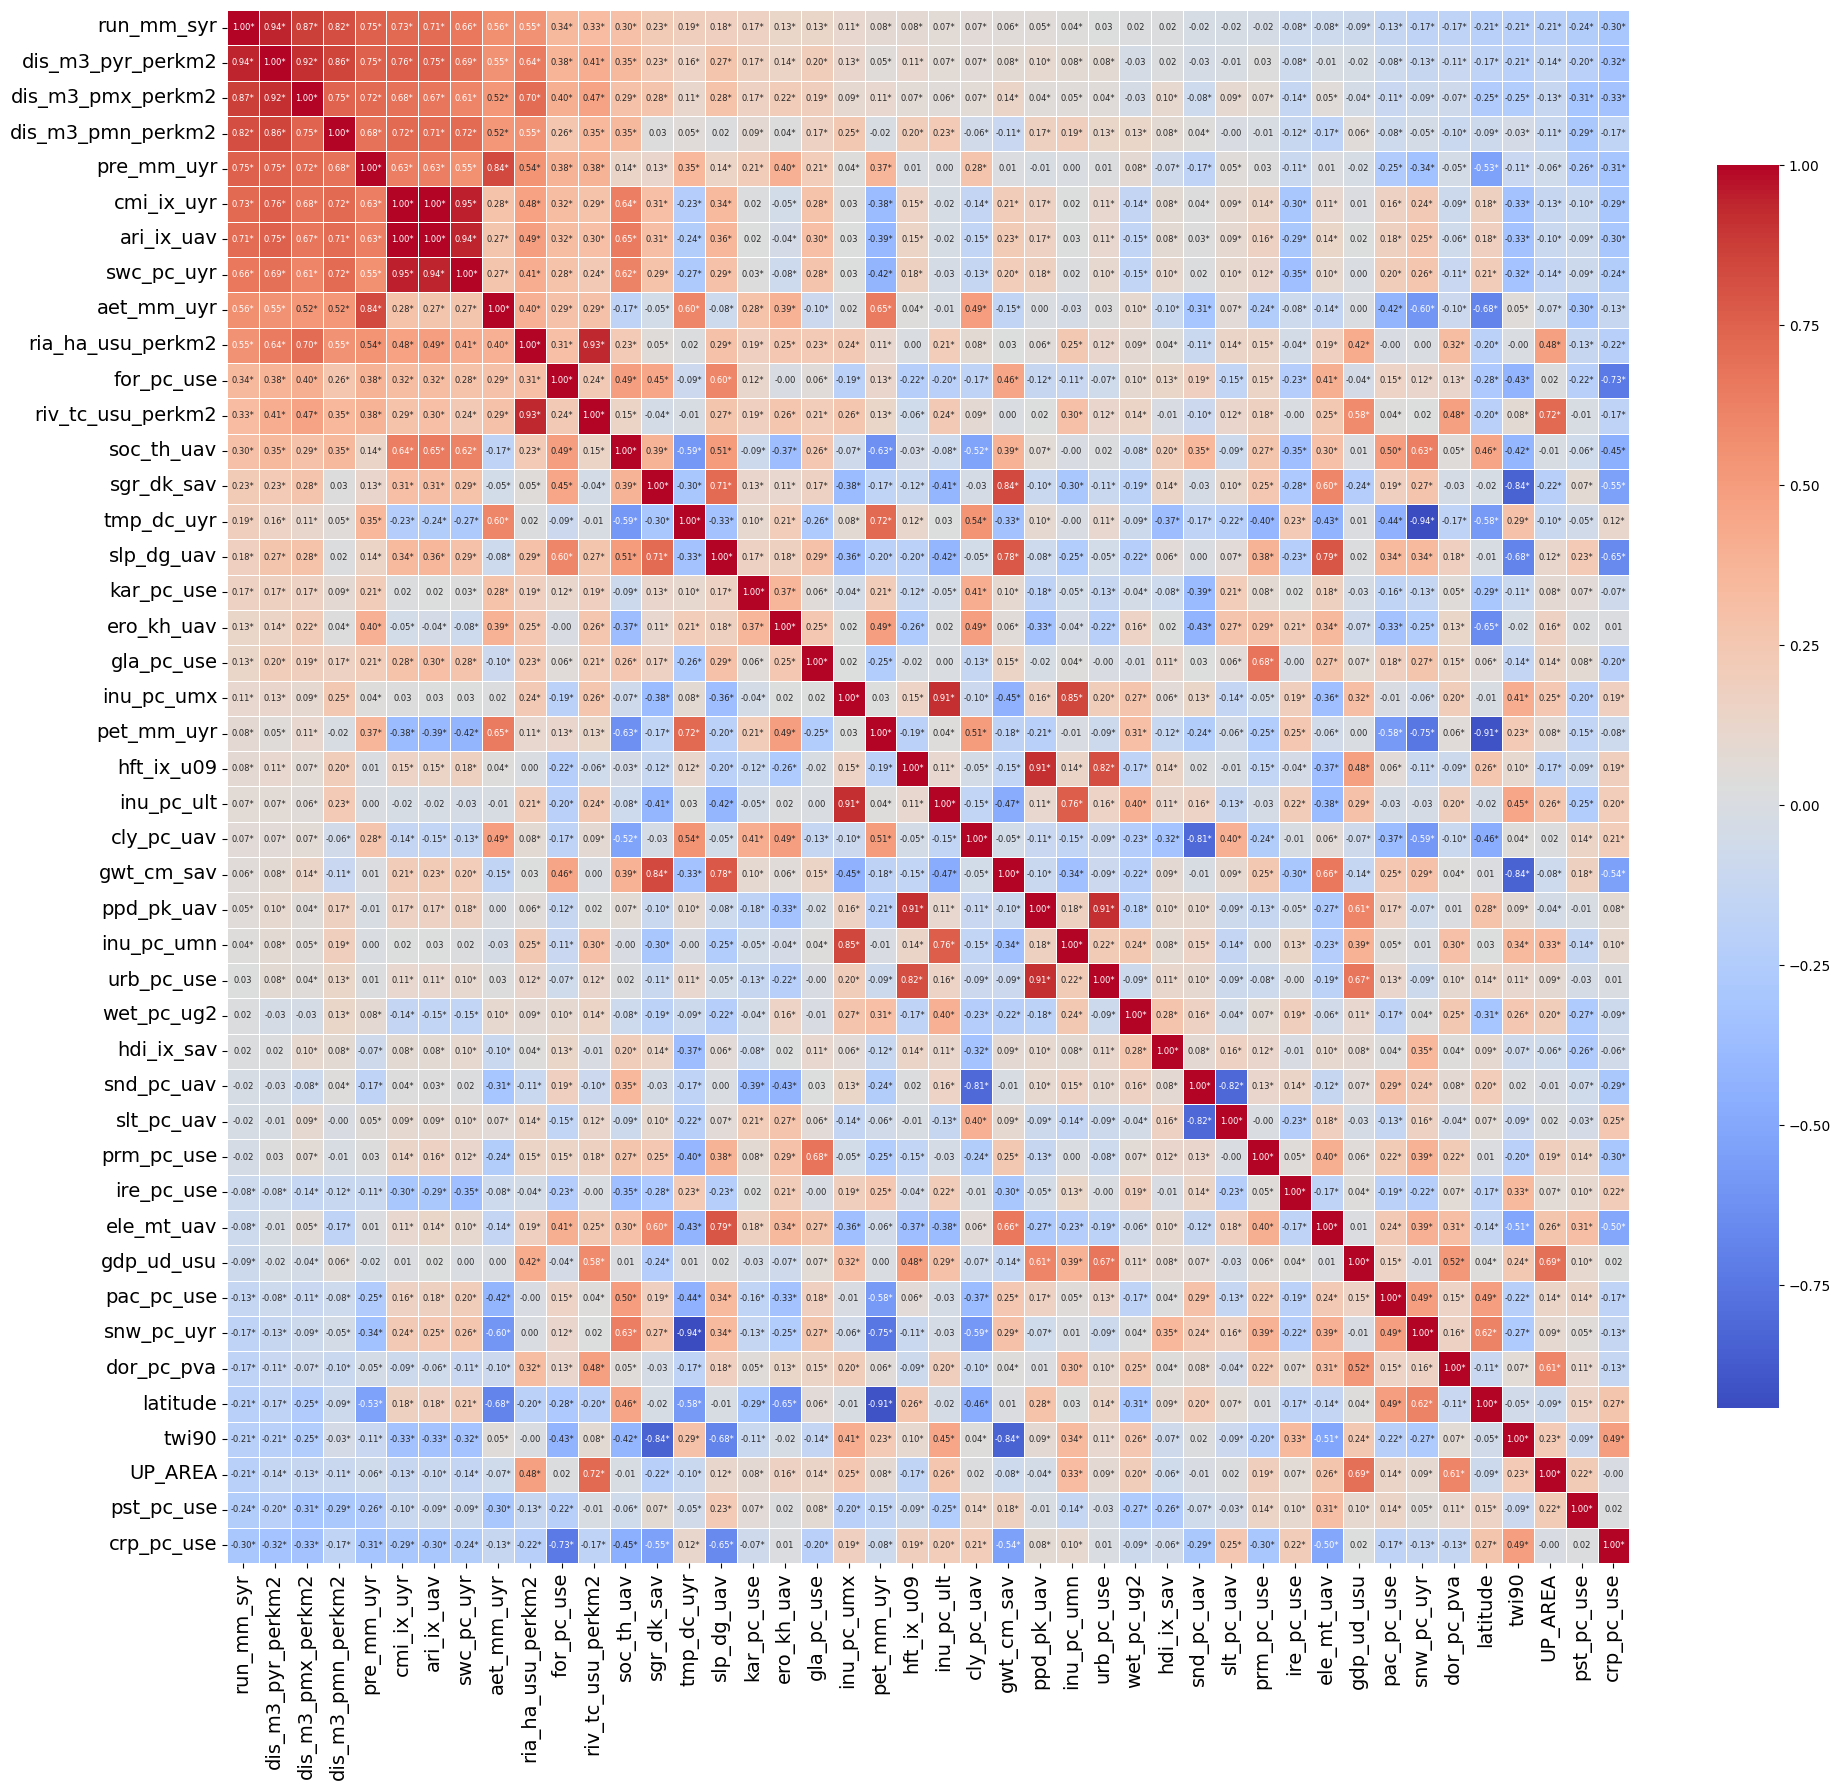

In [30]:


corr_matrix = pd.DataFrame(index = basin_features.columns, columns = basin_features.columns)
p_values = pd.DataFrame(index = basin_features.columns, columns = basin_features.columns)
    
# Calculate correlations and p-values between each pair of variables:
for col1 in basin_features.columns:
    for col2 in basin_features.columns:
        corr, p = spearmanr(basin_features[col1], basin_features[col2])
        corr_matrix.at[col1, col2] = corr
        p_values.at[col1, col2] = p
    
    
# now sort columns of correlation matrix by descending correlation strength:
    
correlations_sorted = corr_matrix['run_mm_syr'].sort_values(ascending = False)
sorted_cols = correlations_sorted.index.to_list()
    
#sort rows and columns of correlation matrix and p_value_matrix
sorted_corr_matrix = corr_matrix.loc[sorted_cols, sorted_cols]
    
sorted_p_values = p_values.loc[sorted_cols, sorted_cols]
    
    
    
# create a heatmap and annotate:
    
plt.figure(figsize = (20, 18))
ax = sns.heatmap(sorted_corr_matrix.astype(float), annot = True, fmt = ".2f", cmap = "coolwarm",
               linewidths = .5, cbar_kws = {"shrink":0.8},
                annot_kws = {"size":6})

ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)
# Loop over data dimensions and create text annotations:
    
for i, row in enumerate(sorted_corr_matrix.index):
    for j, col in enumerate(sorted_corr_matrix.columns):
        if sorted_p_values.iloc[i, j] <0.05:
            # add significance asterisk:
            text = plt.gca().texts[i * len(sorted_corr_matrix.columns) + j]
            plt.gca().texts[i * len(sorted_corr_matrix.columns) + j].set_text(text.get_text() + '*')
    
#plt.title(f"Spearmans rank correlation Heatmap", size = 16)
plt.tight_layout()
plt.show()